# Lab Work — 2.5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Q1 Normal Equation – Basic Implementation

In [2]:
# Dataset with 2 features and 10 samples

X=np.array([
[1,2],
[2,3],
[3,4],
[4,5],
[5,6],
[6,7],
[7,8],
[8,9],
[9,10],
[10,11]
])

y=np.array([5,7,9,11,13,15,17,19,21,23])

# Add bias column
ones=np.ones((X.shape[0],1))
X_b=np.hstack((ones,X))

# Normal Equation
beta=np.linalg.pinv(X_b.T@X_b)@(X_b.T@y)

print('Coefficient Vector:')
print(beta)

Coefficient Vector:
[1.33333333 0.33333333 1.66666667]


# Q2 Prediction using Normal Equation

In [3]:
new_X=np.array([
[11,12],
[12,13],
[13,14]
])

new_X_b=np.hstack((np.ones((3,1)),new_X))

predictions=new_X_b@beta

print('Predictions:')
print(predictions)

Predictions:
[25. 27. 29.]


# Q3 Cost Function Tracking

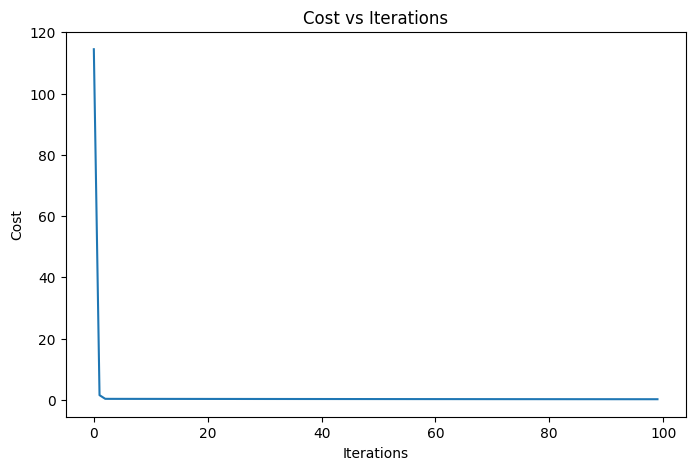

In [4]:
m=len(y)
theta=np.zeros(3)

learning_rate=.01
iterations=100

cost_history=[]

for i in range(iterations):

 predictions=X_b@theta

 error=predictions-y

 cost=(1/(2*m))*np.sum(error**2)

 cost_history.append(cost)

 gradient=(1/m)*X_b.T@error

 theta=theta-learning_rate*gradient

plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs Iterations')
plt.show()

# Q4 Effect of Learning Rate

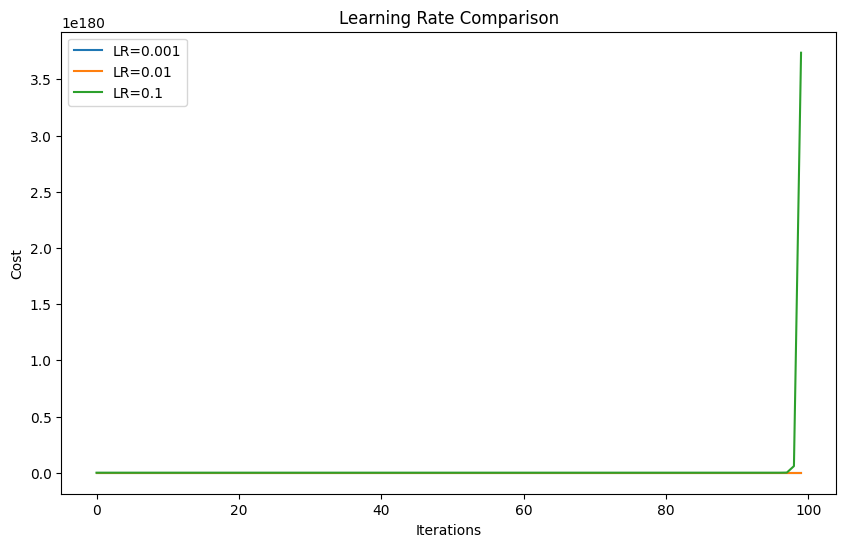

In [5]:
learning_rates=[0.001,0.01,0.1]

plt.figure(figsize=(10,6))

for lr in learning_rates:

 theta=np.zeros(3)

 cost_history=[]

 for i in range(100):

     predictions=X_b@theta

     error=predictions-y

     cost=(1/(2*m))*np.sum(error**2)

     cost_history.append(cost)

     gradient=(1/m)*X_b.T@error

     theta=theta-lr*gradient

 plt.plot(cost_history,label=f'LR={lr}')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Rate Comparison')
plt.show()

# Q5 Real Dataset Implementation

In [6]:
housing=fetch_california_housing()

X=housing.data[:,0:2]
y=housing.target

scaler=StandardScaler()

X=scaler.fit_transform(X)

ones=np.ones((X.shape[0],1))
X_b=np.hstack((ones,X))

beta=np.linalg.inv(X_b.T@X_b)@X_b.T@y

print('Coefficients:')
print(beta)

pred=X_b[:5]@beta

print('\nPredictions:')
print(pred)

print('\nActual Values:')
print(y[:5])

Coefficients:
[2.06855817 0.82011779 0.21950373]

Predictions:
[4.20712626 3.84802511 3.93802043 3.24114019 2.465433  ]

Actual Values:
[4.526 3.585 3.521 3.413 3.422]
